<a href="https://colab.research.google.com/github/tsunoda-data/crm-portfolio/blob/main/crm_portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os

# 1. ルートディレクトリに移動
%cd /content

# 2. 既に存在する古いフォルダを完全に削除
!rm -rf crm-portfolio

# 3. GitHubから最新コードを取得
!git clone https://github.com/tsunoda-data/crm-portfolio.git

# 4. プロジェクトのディレクトリに移動
%cd /content/crm-portfolio

# 5. build_ipynb.py の実行（nb1.py 〜 nb4.py をまとめて変換）
for i in range(1, 5):
    !python scripts/build_ipynb.py scripts/nb{i}.py nb{i}.ipynb

# 6. nb1.py の中身を実行して結果を表示
%run scripts/nb1.py


/content
Cloning into 'crm-portfolio'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 44 (delta 18), reused 4 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 23.41 KiB | 1.95 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/crm-portfolio
Created nb1.ipynb
Created nb2.ipynb
Created nb3.ipynb
Created nb4.ipynb
データ生成を開始します...
データ生成完了: 10000行 × 28列
意図的な汚れ（欠損・外れ値・矛盾など）を注入します...
汚れ注入完了！
データクレンジングを開始します...
  ✅ 個人情報のハッシュ化と削除
  ✅ 日付型の変換
  ✅ 表記揺れの修正
  ✅ 外れ値のキャップ処理 (IQR法)
  ✅ ビジネス矛盾の修正
  ✅ 欠損値の補完
  ✅ 派生変数の再計算
--- 最終データの品質確認 ---
  ✅ アサーションテスト全パス！
✅ データを保存しました: /Users/user/projects/crm-portfolio/notebooks/data/notebook1_cleaned_data.parquet
   データ形状: 10000行 × 28列


✅ データ読み込み完了: 10000行 × 28列
--- ファンベース分析（上位20%の売上貢献度） ---
上位20%の顧客が全体の 55.4% の売上を占めている


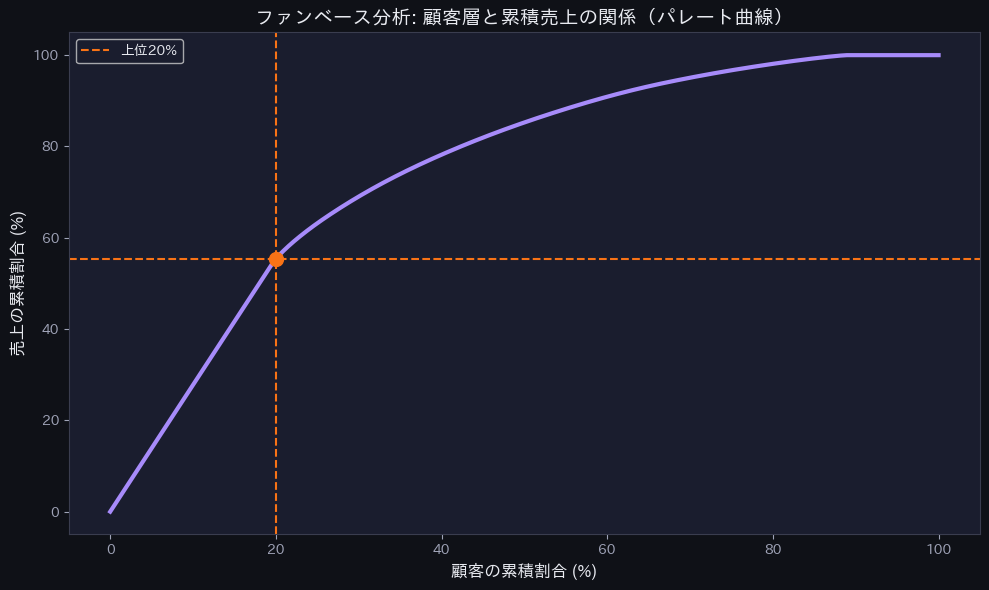

--- NBDモデルによる購買確率の推定 ---
最適化完了: r = 0.9826, alpha = 0.2168


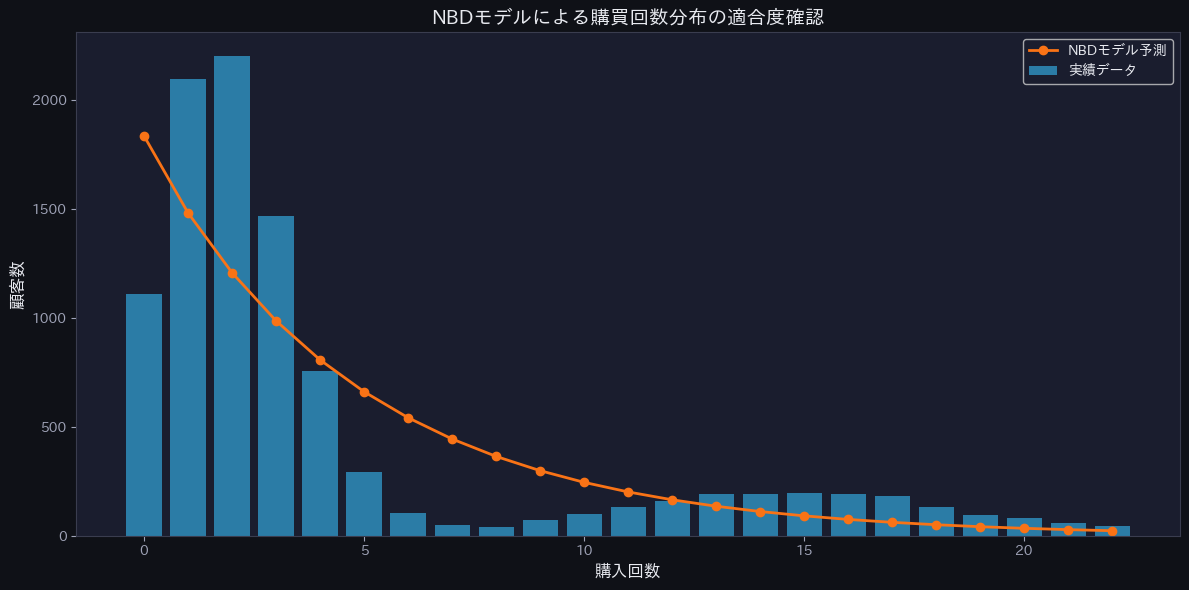

--- コホート分析（月次継続率ヒートマップ） ---


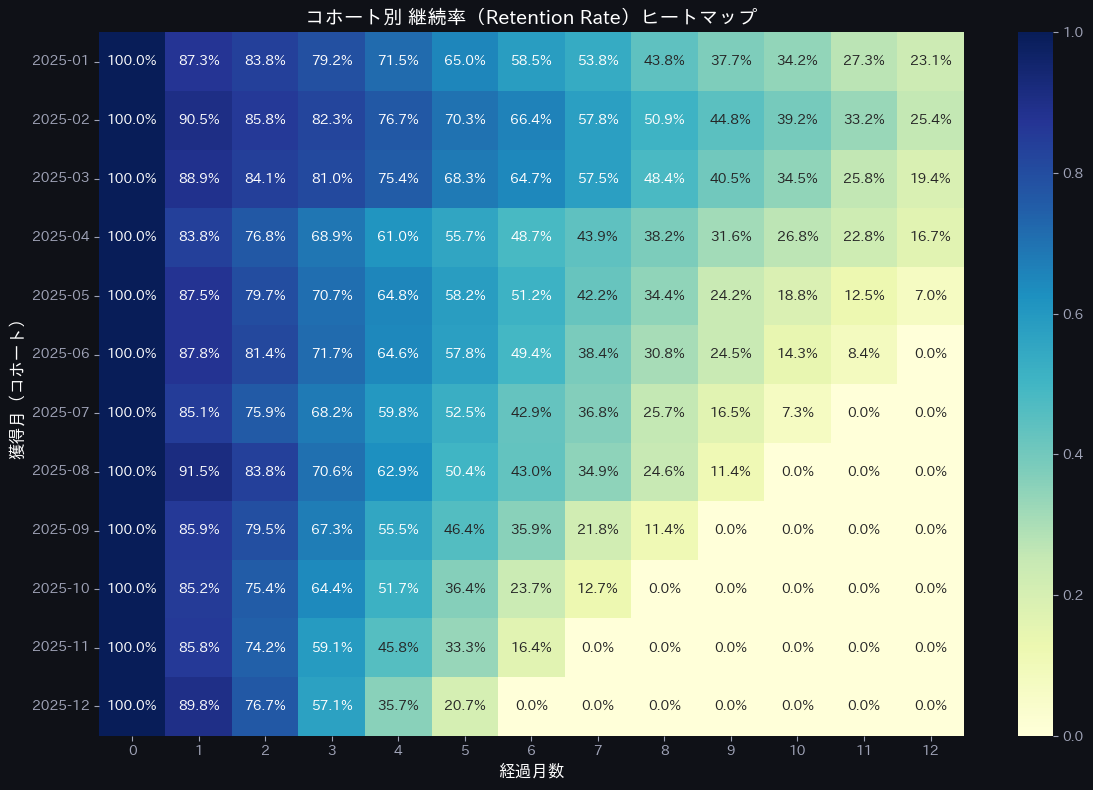

--- 競合ポジショニングマップ（カテゴリ別） ---


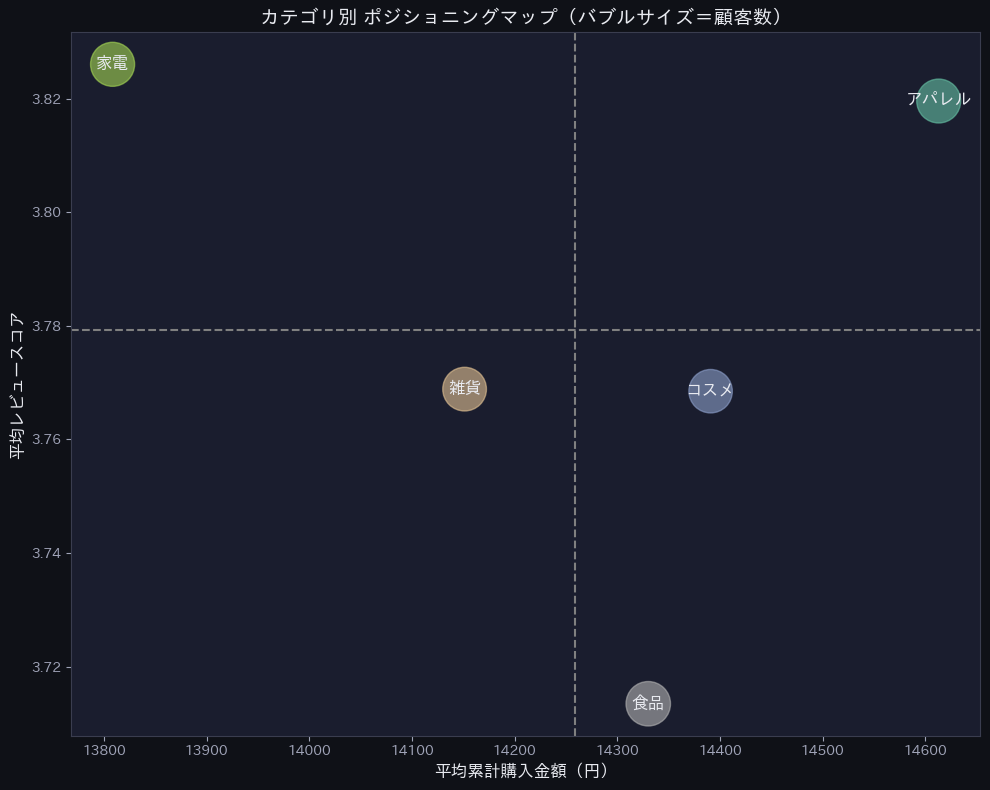

✅ Notebook 2 完了


<Figure size 640x480 with 0 Axes>

In [6]:
%run scripts/nb2.py

✅ データ準備と標準化完了: (10000, 13)
--- K-Means最適クラスタ数の探索 ---


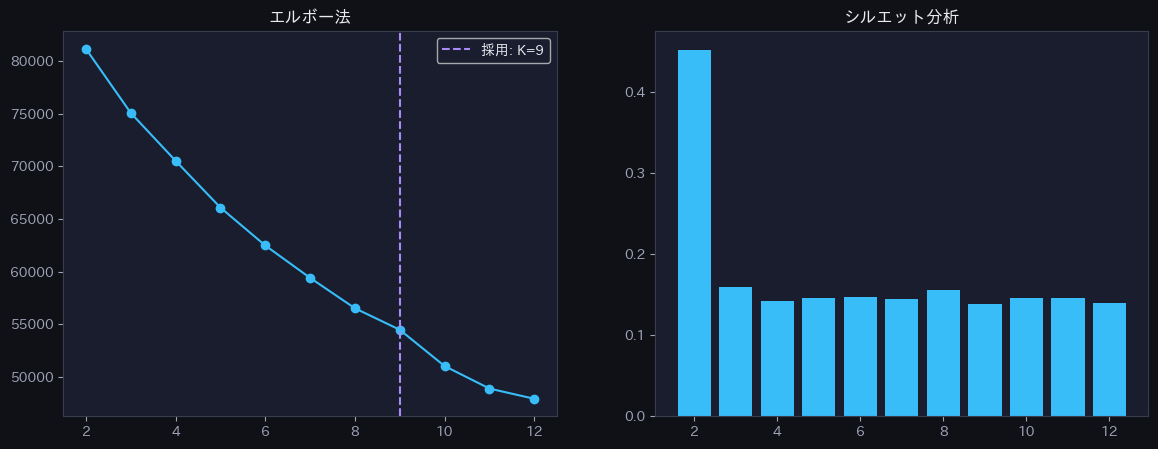

9セグマップに合わせて K=9 を採用します。
--- K=9 クラスタリングと9セグマップへのマッピング ---
基本セグメントの割り当て完了。
--- 松本理論：心理バグセグメントの抽出 ---
segment_label
Seg7_潜在認知顧客     3514
Seg1_ロイヤル顧客     2374
Seg8_深夜葛藤層      1732
Seg4_見込み優良顧客    1172
Seg2_一般顧客       1135
Seg9_低評価中毒層       73
Name: count, dtype: int64
--- 9セグマップのPCA可視化 ---


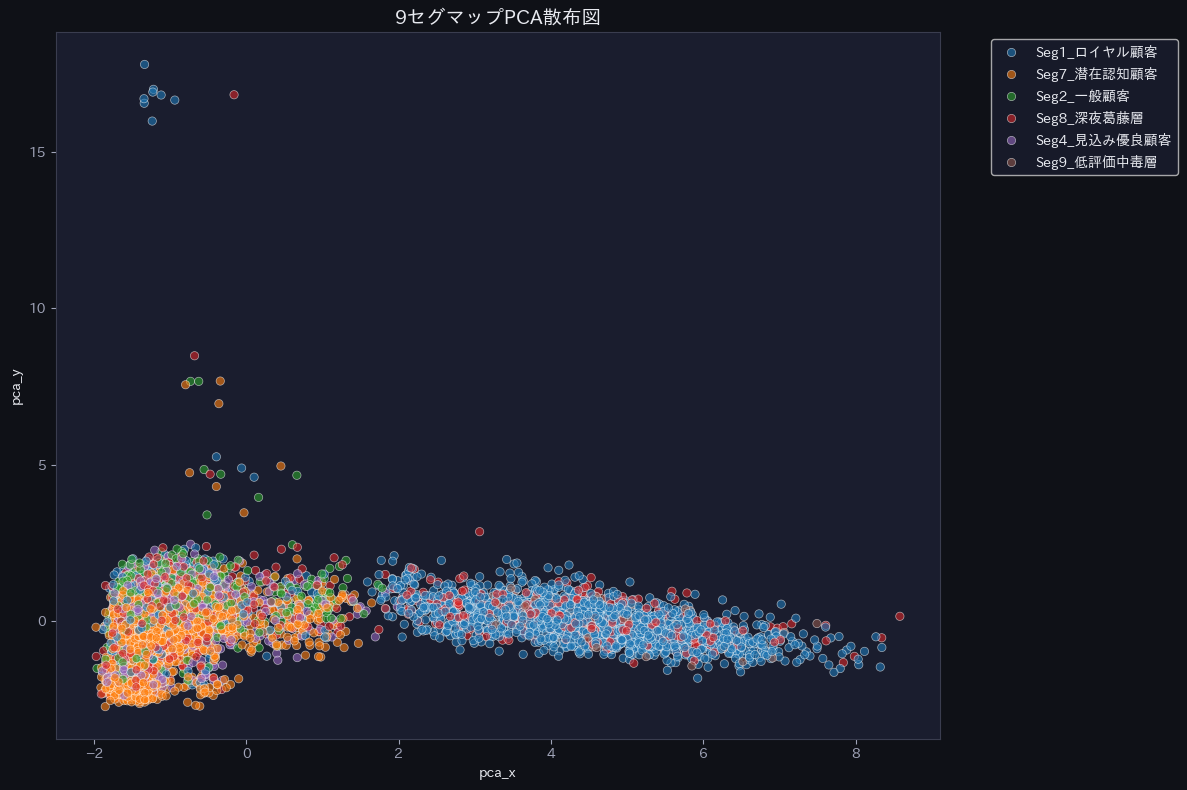

--- セグメント別施策テーブルの出力と保存 ---


,人数,平均購入金額
segment_label,,
Seg1_ロイヤル顧客,2374,28906.9
Seg2_一般顧客,1135,9072.0
Seg4_見込み優良顧客,1172,7602.4
Seg7_潜在認知顧客,3514,7806.5
Seg8_深夜葛藤層,1732,14171.7
Seg9_低評価中毒層,73,38002.9


✅ Notebook 3 完了。データを保存しました: /Users/user/projects/crm-portfolio/notebooks/data/notebook3_segmented_data.parquet


<Figure size 640x480 with 0 Axes>

In [7]:
%run scripts/nb3.py
from sklearn.impute import SimpleImputer

# NaN値がある場合は、Imputerで補完する
imputer = SimpleImputer(strategy='mean')
X_scaled_imputed = imputer.fit_transform(X_scaled)

# KMeans最適クラスタ数の探索
inertias = []
sil_scores = []
K_RANGE = range(2, 11)
for k in K_RANGE:
    kmeans_k = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = kmeans_k.fit_predict(X_scaled_imputed) # 補完済みのデータを使用
    inertias.append(kmeans_k.inertia_)
    sil = silhouette_score(X_scaled_imputed, labels_k, sample_size=3000, random_state=42)
    sil_scores.append(sil)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [8]:
%run scripts/nb4.py

✅ 離脱予測のデータ準備完了
--- 離脱予測モデルの学習 ---
[100]	train's auc: 1	valid's auc: 0.998437
✅ 離脱予測 AUC-ROC スコア: 0.9985
--- LTV予測モデルの学習 ---
[100]	train's rmse: 1000.68	valid's rmse: 1315.3
[200]	train's rmse: 845.413	valid's rmse: 1251.48
[300]	train's rmse: 750.559	valid's rmse: 1241.24
✅ LTV予測 R2スコア: 0.9915, RMSE: ¥1,236
--- クーポンROI最適化シミュレーション ---
✅ 最適クーポン: Seg7_潜在認知顧客 に 5% 割引 (ROI: 190.7%)
--- AIパーソナライズメッセージ自動生成 ---


,セグメント,件名,本文
0,Seg1_ロイヤル顧客,VIPのあなたへ、特別なご案内です,いつもご愛顧いただきありがとうございます。感謝を込めて、コスメカテゴリに5%OFFの限定クー...
1,Seg2_一般顧客,一般顧客の皆様へ特別なご案内,家電カテゴリの商品が5%OFFになるクーポンをお届けします。
2,Seg4_見込み優良顧客,見込み優良顧客の皆様へ特別なご案内,雑貨カテゴリの商品が5%OFFになるクーポンをお届けします。
3,Seg7_潜在認知顧客,潜在認知顧客の皆様へ特別なご案内,食品カテゴリの商品が5%OFFになるクーポンをお届けします。
4,Seg8_深夜葛藤層,迷っているあなたへ。今夜だけの決断を,ずっと気になっていたアパレル商品に、今夜限り5%OFFクーポンをご用意しました。後悔しないために。


✅ 全セグメントのメッセージ生成完了
--- 全体パイプライン関数化 (main) ---
🚀 CRMパイプラインの実行完了
🎉 全4ノートブックの作成完了！
